### Notebook 5 — Churn Classification (Dự đoán khách hàng rời bỏ)
**Người phụ trách:** Ngô Đức Huân — 52400192 — Classification Lead (Churn)

**Bộ dữ liệu:** [Online Retail II — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii)

---

**Input:** `Data/Processed/Transactions_Clean.csv`

**Output:**
- `Data/Interim/Churn_Model_Results.csv` — Bảng so sánh 3 thuật toán.
- `Data/Interim/Customer_Churn_Predictions.csv` — Dự đoán theo từng khách hàng.
- `Models/*.pkl` — Các mô hình đã huấn luyện.

---

**Mục lục:**
1. Đọc dữ liệu giao dịch
2. Phân tích inter-purchase gap → Chốt cửa sổ churn
3. Tách Train/Test theo thời gian bằng 2 mốc Snapshot
4. Xây dựng đặc trưng và nhãn cho từng tập
5. Xử lý mất cân bằng lớp bằng SMOTE (Chỉ trên Train)
6. Huấn luyện và đánh giá 3 thuật toán
7. So sánh phản biện + Phân tích độ quan trọng đặc trưng
---

### 0. Chuẩn bị môi trường

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Xác định thư mục gốc project để Notebook có thể import Source/
PROJECT_NOW = Path.cwd()
if (PROJECT_NOW / "Source").exists():
    PROJECT_ROOT_TAM = PROJECT_NOW
else:
    PROJECT_ROOT_TAM = PROJECT_NOW.parent
sys.path.insert(0, str(PROJECT_ROOT_TAM))

from Source.Utils.IO import (load_csv, save_to_csv, get_project_root, PROCESSED_DATA_DIR, INTERIM_DATA_DIR, MODELS_DIR,)
from Source.Utils.Visualization import (set_plot_style, save_current_figure, PRIMARY_COLOR, SECONDARY_COLOR, ALERT_COLOR,)
from Source.RFM.RFM_Calculator import calculate_rfm
from Source.Churn.Label_Generator import (compute_inter_purchase_gaps, summarize_gap_distribution, suggest_churn_window, generate_churn_labels, build_time_based_snapshots, add_churn_features,)
from Source.Churn.Models import (apply_smote, train_decision_tree, train_random_forest, train_naive_bayes, save_model,)
from Source.Churn.Evaluation import (evaluate_model, build_comparison_table, plot_confusion_matrix, plot_roc_curves, get_feature_importance,)

set_plot_style()
print(f"Thư mục gốc dự án: {get_project_root()}")

Thư mục gốc dự án: D:\Lilith\Customer-Analytics-for-E-Commerce


### 1. Đọc dữ liệu giao dịch

Đọc thẳng `Transactions_Clean.csv` thay vì dùng `Customer_Churn_Features.csv` có sẵn.

Vì để tách Train/Test theo thời gian, nhóm cần tính đặc trưng RFM tại 2 mốc Snapshot khác nhau, trong khi file `Customer_Churn_Features.csv` chỉ chứa một mốc.

In [2]:
transactions = load_csv(PROCESSED_DATA_DIR / "Transactions_Clean.csv", date_columns=["InvoiceDate"])

# Bài toán Churn cần định danh khách hàng nên loại các dòng thiếu Customer ID.
transactions = transactions[transactions["Customer ID"].notna()].copy()


# Tạo TotalPrice để dùng cho tính RFM
transactions["TotalPrice"] = (transactions["Quantity"] * transactions["Price"])


print(f"Số dòng giao dịch có định danh khách hàng: {len(transactions):,}")
print(f"Số khách hàng duy nhất: {transactions['Customer ID'].nunique():,}")
print(f"Khoảng thời gian: {transactions['InvoiceDate'].min().date()} → {transactions['InvoiceDate'].max().date()}")
print(f"\nCác cột hiện có: {transactions.columns.tolist()}"
)

Số dòng giao dịch có định danh khách hàng: 776,642
Số khách hàng duy nhất: 5,853
Khoảng thời gian: 2009-12-01 → 2011-12-09

Các cột hiện có: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'TotalPrice']


### 2. Phân tích inter-purchase gap → Chốt cửa sổ churn

In [3]:
gaps = compute_inter_purchase_gaps(transactions)

print(f"\nThống kê mô tả khoảng cách giữa 2 lần mua liên tiếp (Ngày):")
print(gaps.describe().round(1))

[Compute Inter Purchase Gaps] Thu được 27,030 khoảng cách từ 4,179 khách mua lặp lại.
[Compute Inter Purchase Gaps] Có 1,674 khách chỉ mua đúng 1 lần (28.6%) 

Thống kê mô tả khoảng cách giữa 2 lần mua liên tiếp (Ngày):
count    27030.0
mean        59.3
std         78.3
min          1.0
25%         13.0
50%         32.0
75%         70.0
max        714.0
Name: InterPurchaseGap, dtype: float64


In [4]:
# Tóm tắt phân phối inter-purchase gap

gap_summary = summarize_gap_distribution(gaps)

gap_summary_display = gap_summary.rename(
    columns={
        "percentile": "Percentile",
        "gap_days": "Gap (ngày)",
        "y_nghia": "Ý nghĩa",
    }
)

pd.set_option("display.max_colwidth", None)
gap_summary_display

,Percentile,Gap (ngày),Ý nghĩa
0,P50,32.0,50% Số lần mua liên tiếp cách nhau không quá 32 ngày
1,P60,42.0,60% Số lần mua liên tiếp cách nhau không quá 42 ngày
2,P70,58.0,70% Số lần mua liên tiếp cách nhau không quá 58 ngày
3,P75,70.0,75% Số lần mua liên tiếp cách nhau không quá 70 ngày
4,P80,88.0,80% Số lần mua liên tiếp cách nhau không quá 88 ngày
5,P85,112.0,85% Số lần mua liên tiếp cách nhau không quá 112 ngày
6,P90,148.0,90% Số lần mua liên tiếp cách nhau không quá 148 ngày
7,P95,221.0,95% Số lần mua liên tiếp cách nhau không quá 221 ngày


Đã lưu biểu đồ: D:\Lilith\Customer-Analytics-for-E-Commerce\Figures\10. Inter Purchase Gap.png


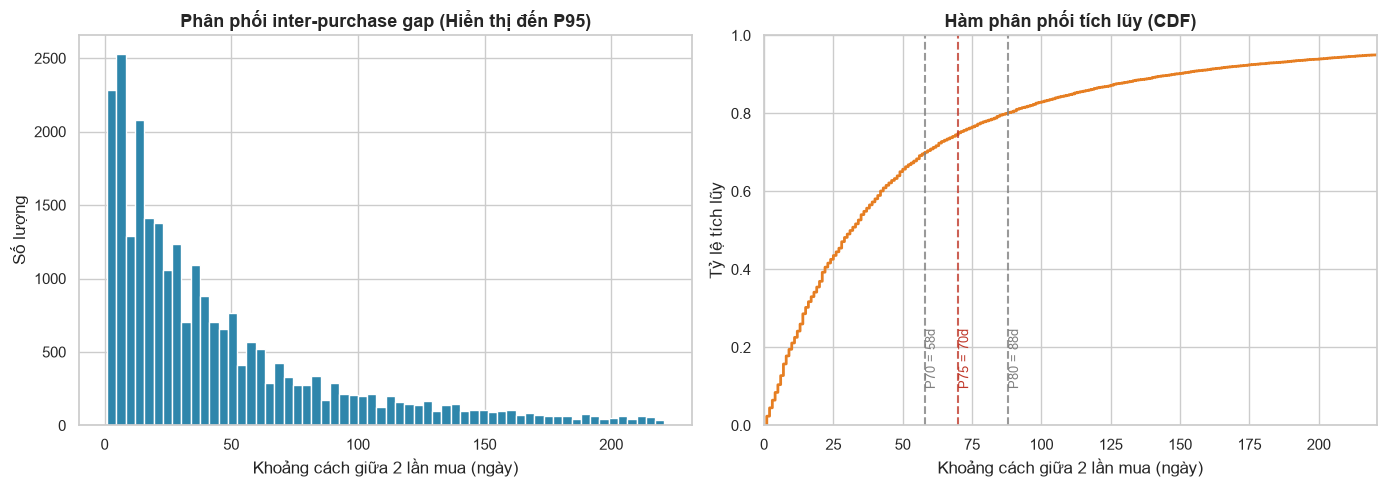

In [5]:
# Trực quan hóa phân phối inter-purchase gap

p95_gap = gaps.quantile(0.95)
fig, (ax_hist, ax_cdf) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: Chỉ hiển thị đến P95 để phần lớn dữ liệu dễ quan sát hơn.
ax_hist.hist(gaps[gaps <= p95_gap], bins=60, color=PRIMARY_COLOR)
ax_hist.set_xlabel("Khoảng cách giữa 2 lần mua (ngày)")
ax_hist.set_ylabel("Số lượng")
ax_hist.set_title("Phân phối inter-purchase gap ""(Hiển thị đến P95)")


# Biểu đồ CDF
sorted_gaps = np.sort(gaps.dropna().to_numpy())
cumulative_ratio = (np.arange(1, len(sorted_gaps) + 1) / len(sorted_gaps))
ax_cdf.plot(sorted_gaps, cumulative_ratio, color=SECONDARY_COLOR, linewidth=2)
ax_cdf.set_xlim(0, p95_gap)
ax_cdf.set_ylim(0, 1)
ax_cdf.set_xlabel("Khoảng cách giữa 2 lần mua (ngày)")
ax_cdf.set_ylabel("Tỷ lệ tích lũy")
ax_cdf.set_title("Hàm phân phối tích lũy (CDF)")


# Đánh dấu các percentile đang cân nhắc
for percentile, line_color in [(0.70, "gray"), (0.75, ALERT_COLOR), (0.80, "gray"),]:
    gap_value = gaps.quantile(percentile)
    ax_cdf.axvline(x=gap_value, color=line_color, linestyle="--", alpha=0.8)
    ax_cdf.text(gap_value, 0.10, f"P{int(percentile * 100)} = {gap_value:.0f}d", rotation=90, color=line_color, fontsize=9)

plt.tight_layout()
save_current_figure("10. Inter Purchase Gap.png")
plt.show()

In [6]:
CHURN_WINDOW_DAYS = suggest_churn_window(gaps, percentile=75)

[Suggest Churn Window] Cửa sổ Churn đề xuất theo P75: 70 ngày.
  ⇒ Khách hàng không quay lại mua trong 70 ngày được coi là đã rời bỏ, vì 75% các chu kỳ mua thực tế đều ngắn hơn khoảng này.


#### **Chọn cửa sổ Churn:**

Nhóm chọn **Percentile 75 (P75)** làm cơ sở đề xuất cửa sổ Churn. Với dữ liệu hiện tại, **P75 = 70 ngày**, tức là **75% các khoảng cách giữa hai lần mua liên tiếp quan sát được không vượt quá 70 ngày**. Nhóm sử dụng mốc này vì các lý do sau:

- **Không quá ngắn:** P50 của phân phối là **32 ngày**. Đây là một ngưỡng tương đối ngắn so với nhiều chu kỳ mua quan sát được trong dữ liệu. Nếu chọn một cửa sổ quá ngắn, những khách hàng có chu kỳ mua vốn dài hơn vẫn có thể bị đánh dấu là không quay lại trong cửa sổ và làm tăng nguy cơ tạo ra nhãn khó phân biệt. Tuy nhiên, mức độ ảnh hưởng thực tế cần được kiểm tra bằng tỷ lệ churn sau khi sinh nhãn.

- **Không quá dài:** P90 và P95 tương ứng lần lượt với **148 ngày và 221 ngày**. Các cửa sổ dài hơn sẽ cho doanh nghiệp một khoảng thời gian dài hơn trước khi một khách hàng được gắn nhãn Churn, từ đó có thể làm giảm tính kịp thời của hoạt động giữ chân. Đồng thời, cửa sổ dài hơn **có thể** làm giảm tỷ lệ khách được gắn nhãn Churn và tạo mất cân bằng lớp lớn hơn.

- **P75 là lựa chọn cân bằng theo dữ liệu hiện tại:** Mốc **70 ngày** nằm giữa P50 = 32 ngày và P90 = 148 ngày, đại diện cho một ngưỡng không quá khắt khe nhưng cũng không quá dài. Nhóm sử dụng P75 làm **cửa sổ Churn đề xuất ban đầu**, sau đó kiểm tra tỷ lệ Churn, mức độ cân bằng lớp và hiệu quả mô hình để bảo đảm ngưỡng này phù hợp cả về mặt thống kê lẫn nghiệp vụ.

**Giới hạn của cách tiếp cận:** Một ngưỡng 70 ngày được áp dụng chung cho mọi khách hàng, trong khi chu kỳ mua thực tế có thể khác nhau đáng kể giữa các nhóm khách hàng. Một hướng cải tiến là sử dụng thông tin về **`AvgGapDays` của từng khách hàng** để xây dựng ngưỡng cá nhân hóa. Tuy nhiên, đây là hướng mở rộng của mô hình chứ **không phải cơ chế sinh nhãn đang được sử dụng trong phiên bản hiện tại**.


### 3. Tách Train/Test theo thời gian

Bài toán Churn về bản chất là **dự đoán tương lai từ quá khứ**. Nếu chia ngẫu nhiên, tập Test sẽ chứa
những khách hàng thuộc cùng giai đoạn thời gian với tập Train — Mô hình vô tình được "học ké" bối cảnh
thị trường của chính giai đoạn mà nó phải dự đoán (đợt khuyến mãi, mùa cao điểm Giáng Sinh...). Kết
quả đánh giá khi đó lạc quan giả tạo và mô hình sẽ hoạt động kém khi triển khai thật.

Cách giải quyết là dùng **hai mốc Snapshot liên tiếp**, cửa sổ quan sát nhãn không chồng lấn

In [7]:
train_snapshot, test_snapshot = build_time_based_snapshots(transactions, window_days=CHURN_WINDOW_DAYS)

[Build Time Based Snapshots] Ngày cuối dữ liệu: 2011-12-09
  TRAIN: Snapshot = 2011-07-22, cửa sổ quan sát nhãn = (2011-07-22, 2011-09-30]
  TEST : Snapshot = 2011-09-30, cửa sổ quan sát nhãn = (2011-09-30, 2011-12-09]


### 4. Xây dựng đặc trưng và nhãn cho từng tập

Với mỗi mốc Snapshot, quy trình gồm 3 bước:
1. Tính RFM tại Snapshot đó (Chỉ dùng dữ liệu quá khứ)
2. Bổ sung đặc trưng phái sinh: `AvgOrderValue`, `Tenure`, `AvgGapDays`
3. Sinh nhãn Churn từ dữ liệu sau Snapshot

Hai phần (đặc trưng ← quá khứ) và (nhãn ← tương lai) được tách bạch tuyệt đối, đây là rào chắn chống
rò rỉ dữ liệu quan trọng nhất của toàn bộ pipeline.

In [8]:
# Xây dựng dataset tại một mốc snapshot
def build_dataset_at_snapshot(transactions_df, snapshot_date, window_days, set_name):
    print(f"Xây dựng tập {set_name} — Snapshot = {pd.Timestamp(snapshot_date).date()}")
    print("-" * 70)

    
    # Tính RFM tại Snapshot: Chỉ sử dụng giao dịch <= snapshot_date
    rfm_at_snapshot = calculate_rfm(transactions_df, snapshot_date=snapshot_date)

    # Bổ sung đặc trưng phái sinh: Chỉ sử dụng dữ liệu <= snapshot_date
    features = add_churn_features(rfm_at_snapshot, transactions_df, snapshot_date=snapshot_date)

    # Sinh nhãn Churn: Sử dụng cửa sổ tương lai sau snapshot
    labels = generate_churn_labels(transactions_df, snapshot_date=snapshot_date, window_days=window_days)

    # Ghép features + labels
    dataset = features.merge(labels, on="Customer ID", how="inner")

    # Kiểm tra Customer ID duy nhất
    if dataset["Customer ID"].duplicated().any():
        raise ValueError(f"Tập {set_name} có Customer ID bị trùng sau khi Merge.")

    # Kiểm tra Churn không thiếu
    if dataset["Churn"].isna().any():
        raise ValueError(f"Tập {set_name} có nhãn Churn bị thiếu.")

    print(f"→ Tập {set_name}: {len(dataset):,} khách hàng")
    print(f"→ Phân bố Churn: {dataset['Churn'].value_counts().sort_index().to_dict()}")

    return dataset


# Xây dựng TRAIN và TEST
train_dataset = build_dataset_at_snapshot(transactions_df=transactions, snapshot_date=train_snapshot,  window_days=CHURN_WINDOW_DAYS, set_name="TRAIN")

test_dataset = build_dataset_at_snapshot(transactions_df=transactions, snapshot_date=test_snapshot, window_days=CHURN_WINDOW_DAYS, set_name="TEST")

Xây dựng tập TRAIN — Snapshot = 2011-07-22
----------------------------------------------------------------------
[Calculate RFM] Đã loại 0 dòng thiếu 'Customer ID' (Còn lại 776,642 dòng để tính RFM).
[Calculate RFM] Mốc Snapshot Date = 2011-07-22. Đã loại 202,718 dòng có ngày giao dịch Sau mốc này (Còn lại 573,924 dòng).
[Calculate RFM] Đã tính RFM cho 5,081 khách hàng.
[Add Churn Features] Đã bổ sung 3 đặc trưng: AvgOrderValue, Tenure, AvgGapDays cho 5,081 khách hàng.
[Generate Churn Labels] Snapshot = 2011-07-22, cửa sổ = 70 ngày -> 5,081 khách hàng, Churn = 3,522 (69.3%), không Churn = 1,559
→ Tập TRAIN: 5,081 khách hàng
→ Phân bố Churn: {0: 1559, 1: 3522}
Xây dựng tập TEST — Snapshot = 2011-09-30
----------------------------------------------------------------------
[Calculate RFM] Đã loại 0 dòng thiếu 'Customer ID' (Còn lại 776,642 dòng để tính RFM).
[Calculate RFM] Mốc Snapshot Date = 2011-09-30. Đã loại 129,968 dòng có ngày giao dịch Sau mốc này (Còn lại 646,674 dòng).
[Calcula

In [9]:
# Tách đặc trưng và nhãn
FEATURE_COLUMNS = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "Tenure", "AvgGapDays",]
TARGET_COLUMN = "Churn"

# Kiểm tra các cột cần thiết tồn tại
required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]

for dataset_name, dataset in [("TRAIN", train_dataset), ("TEST", test_dataset),]:
    missing_columns = [column for column in required_columns if column not in dataset.columns]
    if missing_columns:
        raise KeyError(f"Tập {dataset_name} thiếu các cột: {missing_columns}")


# Tách X và y
X_train = train_dataset[FEATURE_COLUMNS].copy()
y_train = train_dataset[TARGET_COLUMN].copy()

X_test = test_dataset[FEATURE_COLUMNS].copy()
y_test = test_dataset[TARGET_COLUMN].copy()

# Kiểm tra kích thước
print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}  |  y_test : {y_test.shape}")

# Kiểm tra tỷ lệ Churn
print(f"\nTỷ lệ Churn tập Train: {y_train.mean() * 100:.1f}%")
print(f"Tỷ lệ Churn tập Test : {y_test.mean() * 100:.1f}%")

X_train: (5081, 6)  |  y_train: (5081,)
X_test : (5404, 6)  |  y_test : (5404,)

Tỷ lệ Churn tập Train: 69.3%
Tỷ lệ Churn tập Test : 60.6%


Đã lưu biểu đồ: D:\Lilith\Customer-Analytics-for-E-Commerce\Figures\11. Class Distribution.png


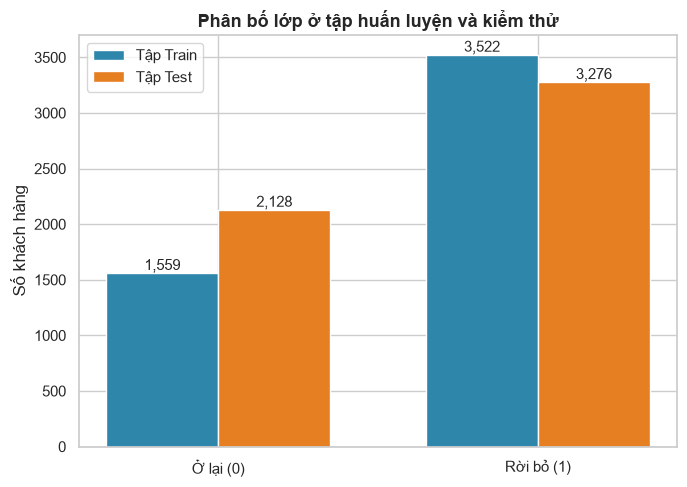

In [10]:
# Trực quan hóa phân bố lớp TRAIN và TEST

fig, ax = plt.subplots(figsize=(7, 5))
label_names = ["Ở lại (0)", "Rời bỏ (1)"]

train_counts = [(y_train == 0).sum(), (y_train == 1).sum()]
test_counts = [(y_test == 0).sum(), (y_test == 1).sum()]

x_positions = np.arange(2)
bar_width = 0.35


# Vẽ TRAIN
ax.bar(x_positions - bar_width / 2, train_counts, bar_width, label="Tập Train", color=PRIMARY_COLOR)

# Vẽ TEST
ax.bar(x_positions + bar_width / 2, test_counts, bar_width, label="Tập Test", color=SECONDARY_COLOR)

ax.set_xticks(x_positions)
ax.set_xticklabels(label_names)
ax.set_ylabel("Số khách hàng")
ax.set_title("Phân bố lớp ở tập huấn luyện và kiểm thử")
ax.legend()


for i, (train_value, test_value) in enumerate(zip(train_counts, test_counts)):
    ax.text(i - bar_width / 2, train_value, f"{train_value:,}", ha="center", va="bottom")
    ax.text(i + bar_width / 2, test_value, f"{test_value:,}", ha="center", va="bottom")

plt.tight_layout()
save_current_figure("11. Class Distribution.png")
plt.show()

#### **Phát hiện khác với giả định ban đầu**

Kế hoạch ban đầu của nhóm giả định rằng `Churn` sẽ là lớp thiểu số. Tuy nhiên, **dữ liệu thực tế cho thấy Churn đang là lớp đa số**:

* Tập TRAIN: `Churn = 1` chiếm **69.3%**.
* Tập TEST: `Churn = 1` chiếm **60.6%**.

Một nguyên nhân đáng chú ý là trong dữ liệu có **1,674/5,853 khách hàng (28.6%) chỉ có một ngày mua duy nhất**, nên các khách hàng này không đóng góp vào phân phối inter-purchase gap và cần được xử lý trực tiếp khi sinh nhãn. Tuy nhiên, việc một khách hàng chỉ xuất hiện một lần không đồng nghĩa với việc họ chắc chắn được gán `Churn = 1`; nhãn cuối cùng vẫn phụ thuộc vào việc khách hàng có quay lại mua trong cửa sổ 70 ngày sau Snapshot hay không.

Ngoài ra, nhóm sử dụng **70 ngày làm cửa sổ Churn**, tương ứng với P75 của phân phối inter-purchase gap. Đây là một quy ước dựa trên hành vi mua thực tế của tập dữ liệu, không phải một ngưỡng cố định áp dụng từ bên ngoài.

**Hệ quả đối với đánh giá mô hình:** khi `Churn` là lớp đa số, Accuracy có thể tạo cảm giác tích cực nếu mô hình chỉ dự đoán lớp Churn cho phần lớn khách hàng. Vì vậy, Accuracy không được sử dụng như thước đo duy nhất. Nhóm quyết định báo cáo đồng thời **Precision, Recall, F1 và AUC**, đồng thời đưa **Naive Baseline** vào làm mốc tham chiếu để đánh giá mô hình có tạo ra giá trị vượt quá cách dự đoán theo lớp đa số hay không.


### 5. Xử lý mất cân bằng lớp bằng SMOTE — Chỉ trên tập Train

- SMOTE chỉ áp lên tập Train. 

- Tập Test giữ nguyên phân phối thực tế, vì đó mới là điều mô hình sẽ gặp khi triển khai. Áp SMOTE lên Test là lỗi rò rỉ dữ liệu nghiêm trọng.

In [11]:
X_train_balanced, y_train_balanced = apply_smote(X_train, y_train)

print(f"\nTrain trước SMOTE : {len(y_train):,} mẫu")
print(f"Train sau SMOTE   : {len(y_train_balanced):,} mẫu")
print(f"Test giữ nguyên    : {len(y_test):,} mẫu với tỷ lệ Churn {y_test.mean() * 100:.1f}%")

[Apply Smote] Phân bố lớp trước Smote: {0: 1559, 1: 3522} (Tổng 5,081 mẫu)
[Apply Smote] Phân bố lớp sau Smote  : {0: 3522, 1: 3522} (Tổng 7,044 mẫu)
[Apply Smote] Đã sinh thêm 1,963 mẫu nhân tạo cho lớp thiểu số

Train trước SMOTE : 5,081 mẫu
Train sau SMOTE   : 7,044 mẫu
Test giữ nguyên    : 5,404 mẫu với tỷ lệ Churn 60.6%


## 6. Huấn luyện và đánh giá 3 thuật toán

Ba thuật toán được chọn đại diện cho 3 họ phương pháp khác nhau:
- **Decision Tree** — Cây quyết định đơn, dễ diễn giải nhất

- **Random Forest** — Phương pháp tập hợp kiểu Bagging

- **Naive Bayes** — Phương pháp xác suất dựa trên định lý Bayes

In [12]:
trained_models = {}

trained_models["Decision Tree"] = train_decision_tree(X_train_balanced, y_train_balanced)
trained_models["Random Forest"] = train_random_forest(X_train_balanced, y_train_balanced)
trained_models["Naive Bayes"] = train_naive_bayes(X_train_balanced, y_train_balanced)

[Train Decision Tree] Đã huấn luyện xong (Max Depth = 6, Min Samples Leaf = 20, Số lá thực tế = 58).
[Train Random Forest] Đã huấn luyện xong (200 cây, Max Depth = 10).
[Train Naive Bayes] Đã huấn luyện xong (GaussianNB).


In [13]:
print("ĐÁNH GIÁ TRÊN TẬP TEST\n")

all_metrics = []
for model_name, model in trained_models.items():
    metrics = evaluate_model(model, X_test, y_test, model_name)
    all_metrics.append(metrics)
    print()

comparison_table = build_comparison_table(all_metrics)

comparison_table_display = comparison_table.rename(
    columns={
        "model_name": "Model name",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1",
        "auc": "AUC",
        "accuracy": "Accuracy",
        "baseline_accuracy": "Baseline Accuracy",
        "improvement_over_baseline": "Improvement over Baseline"
    }
)

display(comparison_table_display)

ĐÁNH GIÁ TRÊN TẬP TEST

[Evaluate Model] Decision Tree: Precision = 0.7639  |  Recall = 0.7930  |  F1 = 0.7782  |  AUC = 0.7665
    Accuracy = 0.7259 so với Naive Baseline 0.6062 (Chênh lệch +0.1197)

[Evaluate Model] Random Forest: Precision = 0.7652  |  Recall = 0.8129  |  F1 = 0.7883  |  AUC = 0.7872
    Accuracy = 0.7354 so với Naive Baseline 0.6062 (Chênh lệch +0.1292)

[Evaluate Model] Naive Bayes: Precision = 0.7057  |  Recall = 0.9164  |  F1 = 0.7973  |  AUC = 0.7847
    Accuracy = 0.7176 so với Naive Baseline 0.6062 (Chênh lệch +0.1114)



,Model name,Precision,Recall,F1,AUC,Accuracy,Baseline Accuracy,Improvement over Baseline
0,Naive Bayes,0.7057,0.9164,0.7973,0.7847,0.7176,0.6062,0.1114
1,Random Forest,0.7652,0.8129,0.7883,0.7872,0.7354,0.6062,0.1292
2,Decision Tree,0.7639,0.7930,0.7782,0.7665,0.7259,0.6062,0.1197


Đã lưu biểu đồ: D:\Lilith\Customer-Analytics-for-E-Commerce\Figures\12. Confusion Matrices.png


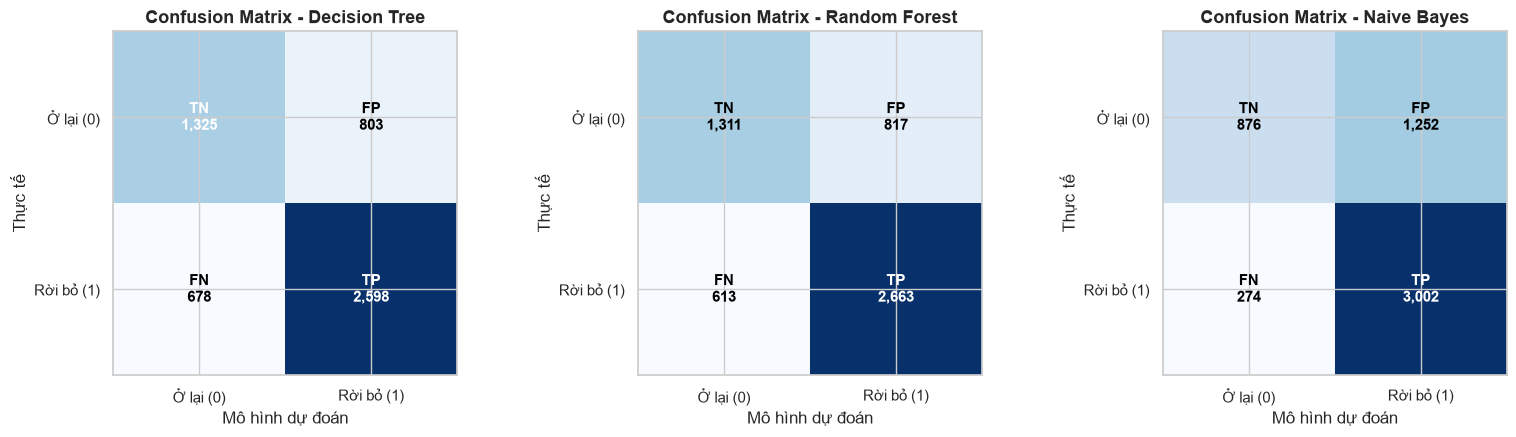

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (model_name, model) in zip(axes, trained_models.items()):
    plot_confusion_matrix(model, X_test, y_test, model_name, ax=ax)

plt.tight_layout()
save_current_figure("12. Confusion Matrices.png")
plt.show()


Đã lưu biểu đồ: D:\Lilith\Customer-Analytics-for-E-Commerce\Figures\13. ROC Curves.png


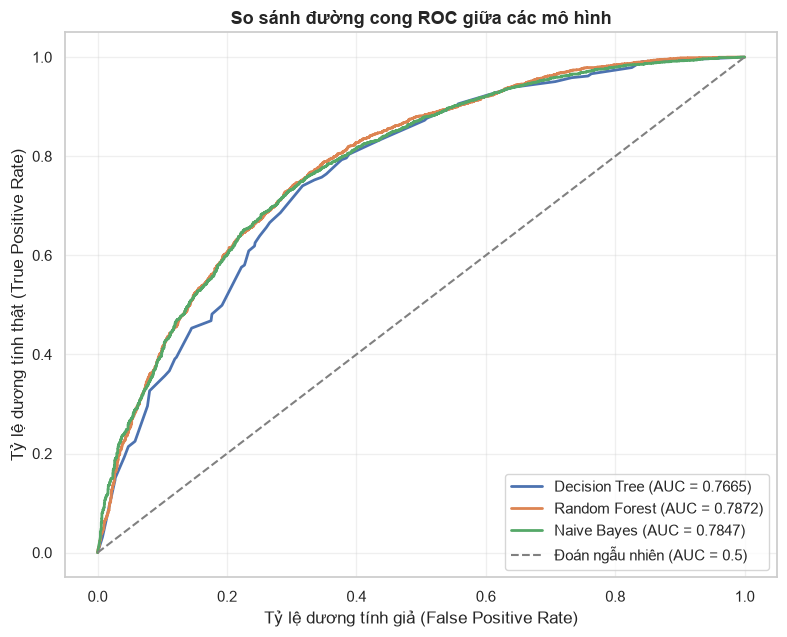

In [15]:
fig, ax = plt.subplots(figsize=(8, 6.5))

plot_roc_curves(trained_models, X_test, y_test, ax=ax)
plt.tight_layout()
save_current_figure("13. ROC Curves.png")
plt.show()


### 7. So sánh phản biện + Phân tích độ quan trọng của đặc trưng

Đã lưu biểu đồ: D:\Lilith\Customer-Analytics-for-E-Commerce\Figures\14. Models Comparison.png


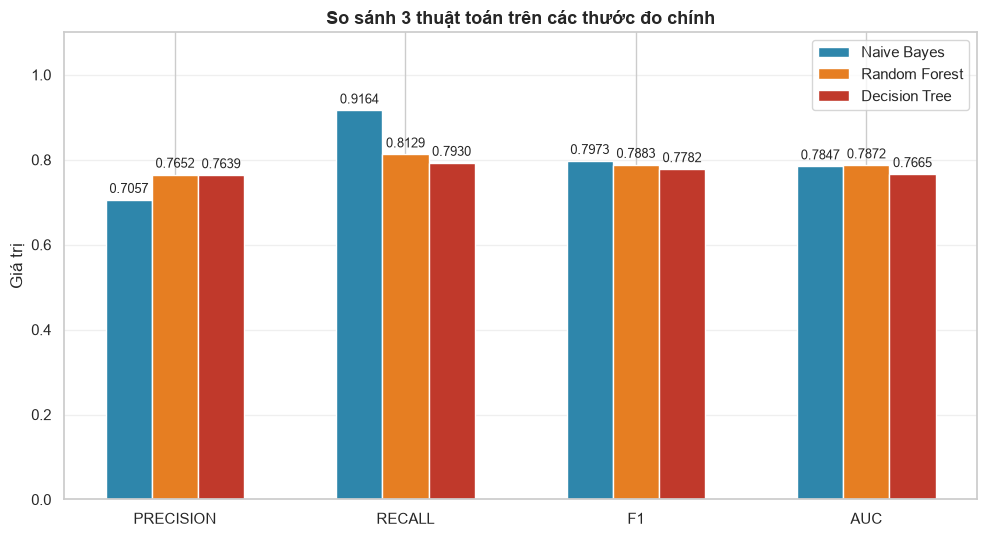

In [16]:
# So sánh 3 mô hình trên các metric chính

fig, ax = plt.subplots(figsize=(10, 5.5))
metrics_to_plot = ["precision", "recall", "f1", "auc"]

n_models = len(comparison_table)
bar_width = 0.2

x_positions = np.arange(len(metrics_to_plot))

colors = [PRIMARY_COLOR, SECONDARY_COLOR, ALERT_COLOR]

for model_index, (_, row) in enumerate(comparison_table.iterrows()):
    offsets = x_positions + (model_index - (n_models - 1) / 2) * bar_width
    values = [row[metric] for metric in metrics_to_plot]
    bars = ax.bar(offsets, values, bar_width, label=row["model_name"], color=colors[model_index % len(colors)])
    ax.bar_label(bars, labels=[f"{value:.4f}" for value in values], padding=3, fontsize=9)

ax.set_xticks(x_positions)
ax.set_xticklabels([metric.upper() for metric in metrics_to_plot])

ax.set_ylabel("Giá trị")
ax.set_ylim(0, 1.10)
ax.set_title("So sánh 3 thuật toán trên các thước đo chính")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
save_current_figure("14. Models Comparison.png")
plt.show()

Đã lưu biểu đồ: D:\Lilith\Customer-Analytics-for-E-Commerce\Figures\15. Feature Importance.png


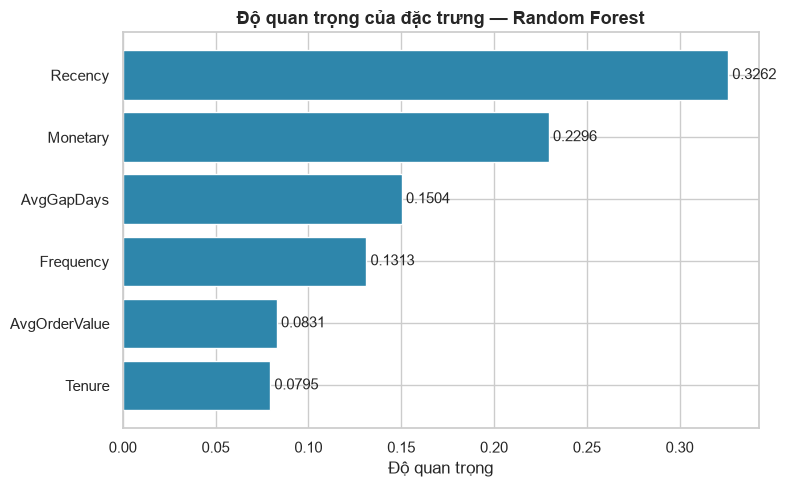

In [20]:
# Độ quan trọng của đặc trưng
random_forest_model = trained_models["Random Forest"]

importance_df = get_feature_importance(random_forest_model, FEATURE_COLUMNS, "Random Forest")

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color=PRIMARY_COLOR)

ax.set_xlabel("Độ quan trọng")
ax.set_title("Độ quan trọng của đặc trưng — Random Forest")

for i, value in enumerate(importance_df["importance"][::-1]):
    ax.text(value, i, f" {value:.4f}", va="center")

plt.tight_layout()
save_current_figure("15. Feature Importance.png")
plt.show()

#### **Nhận xét**

**1. Cả 3 mô hình đều cải thiện rõ rệt so với Baseline, nhưng mức cải thiện không quá lớn**

Cả 3 mô hình đều có Accuracy cao hơn Naive Baseline `0.6062`. Mức cải thiện lần lượt là **+11.97 điểm % đối với Decision Tree, +12.92 điểm % đối với Random Forest và +11.14 điểm % đối với Naive Bayes**. Kết quả cho thấy các mô hình đã học được thông tin hữu ích từ các đặc trưng, nhưng mức cải thiện chưa quá lớn. Vì vậy, không nên chỉ nhấn mạnh Accuracy trên 70% mà cần đặt kết quả trong tương quan với Baseline và các thước đo khác.

**2. Kết quả khác với kỳ vọng ban đầu: Naive Bayes đạt F1 cao nhất**

Kết quả thực nghiệm cho thấy **Naive Bayes đạt F1 cao nhất (`0.7973`)**, cao hơn Random Forest (`0.7883`) và Decision Tree (`0.7782`). Điều này đáng chú ý vì Naive Bayes dựa trên giả định các đặc trưng độc lập có điều kiện, trong khi một số đặc trưng trong bài toán này có quan hệ toán học hoặc có khả năng tương quan với nhau, chẳng hạn `AvgOrderValue` được tính từ `Monetary / Frequency`.

Naive Bayes có **Recall rất cao (`0.9164`)** nhưng **Precision thấp nhất (`0.7057`)**. Điều này cho thấy mô hình có xu hướng gán nhãn Churn khá mạnh: mô hình phát hiện được phần lớn khách hàng thực sự churn nhưng đồng thời tạo ra nhiều cảnh báo nhầm.

Do F1 là trung bình điều hòa của Precision và Recall, một mô hình có Recall cao vẫn có thể đạt F1 tốt dù Precision thấp hơn. Trong dữ liệu Test, Churn chiếm khoảng **60.6%**, do đó cần tránh diễn giải F1 hoặc Accuracy một cách tách biệt khỏi phân phối lớp.

Về AUC, **Random Forest đạt giá trị cao nhất (`0.7872`)**, tiếp theo là Naive Bayes (`0.7847`) và Decision Tree (`0.7665`). Tuy nhiên, chênh lệch giữa Random Forest và Naive Bayes chỉ là **0.0025**, nên chưa có cơ sở để khẳng định Random Forest vượt trội rõ ràng về khả năng phân biệt. Kết quả phù hợp hơn với nhận xét rằng **Random Forest có hồ sơ Metric tương đối cân bằng**, trong khi Naive Bayes nổi bật ở khả năng thu hồi khách hàng có nguy cơ churn.

**3. Đánh đổi Precision — Recall phụ thuộc vào mục tiêu nghiệp vụ**

Naive Bayes phù hợp hơn trong kịch bản doanh nghiệp **ưu tiên Recall**, tức chấp nhận nhiều cảnh báo nhầm hơn để hạn chế bỏ sót khách hàng thực sự có nguy cơ churn.

Ngược lại, khi ngân sách marketing bị giới hạn và doanh nghiệp muốn giảm số khách hàng được nhắm mục tiêu nhầm, **Precision trở nên quan trọng hơn**. Trong kết quả hiện tại, Random Forest có Precision `0.7652`, cao hơn Naive Bayes `0.7057`.

Do đó, không có một mô hình duy nhất tối ưu cho mọi mục tiêu nghiệp vụ. Nếu doanh nghiệp ưu tiên phát hiện càng nhiều khách hàng có nguy cơ càng tốt, có thể xem xét Naive Bayes; nếu muốn cân bằng hơn giữa Precision, Recall và khả năng phân biệt, Random Forest là một ứng viên phù hợp để tiếp tục kiểm nghiệm.

Một hướng cải tiến là **điều chỉnh threshold dự đoán của Random Forest** thay vì cố định ở `0.5` để tìm điểm cân bằng Precision – Recall phù hợp với chi phí nghiệp vụ. Việc lựa chọn threshold cần được thực hiện trên tập Validation, không tối ưu trực tiếp trên tập Test.

**4. Độ quan trọng của đặc trưng**

Kết quả Feature Importance của Random Forest cho thấy các đặc trưng quan trọng nhất là:

* `Recency`: `0.3262`
* `Monetary`: `0.2296`
* `AvgGapDays`: `0.1504`
* `Frequency`: `0.1313`
* `AvgOrderValue`: `0.0831`
* `Tenure`: `0.0795`

Như vậy, các đặc trưng liên quan đến **thời gian mua hàng (`Recency`, `AvgGapDays`)** cùng với **giá trị mua hàng (`Monetary`)** đóng góp lớn vào dự đoán của mô hình. Kết quả này phù hợp với trực giác nghiệp vụ: khoảng thời gian kể từ lần mua gần nhất và khoảng cách giữa các lần mua có thể cung cấp tín hiệu quan trọng về thay đổi hành vi khách hàng.

Tuy nhiên, Feature Importance phản ánh **mức độ đóng góp của đặc trưng vào mô hình**, không chứng minh rằng đặc trưng đó là nguyên nhân gây ra churn. Đây là cơ sở để đề xuất các hướng phân tích sâu hơn, chẳng hạn cá nhân hóa ngưỡng churn theo nhịp mua của từng khách hàng thay vì sử dụng một ngưỡng chung.

**5. Hạn chế của mô hình và hướng cải tiến**

* **Cửa sổ Churn 70 ngày đang được dùng chung cho tất cả khách hàng**, trong khi chu kỳ mua của mỗi khách hàng có thể rất khác nhau. Một khách hàng thường mua mỗi 15 ngày và một khách hàng thường mua mỗi 120 ngày không nên được đánh giá bằng cùng một ngưỡng.
* **Ngưỡng 70 ngày cần được xác định hoàn toàn từ dữ liệu quá khứ của giai đoạn Train.** Trong phiên bản hiện tại, P75 được tính từ toàn bộ dữ liệu, bao gồm cả giai đoạn sau thời điểm Train.
* **Khách hàng chỉ mua một lần chiếm 28.6% tổng số khách hàng (`1,674/5,853`)** và không tạo ra inter-purchase gap. Nhóm này có hành vi khác với khách hàng mua lặp lại, vì vậy nên được phân tích riêng để xác định tỷ lệ quay lại và có thể xây dựng bài toán “repeat purchase” hoặc “first-to-second purchase” riêng.
* **Cửa sổ quan sát của tập Test kết thúc đúng vào ngày cuối cùng của dữ liệu**, nên chưa thể kiểm chứng khả năng dự báo trên một giai đoạn xa hơn.
* **Chưa thực hiện tinh chỉnh siêu tham số một cách hệ thống** bằng GridSearch hoặc RandomizedSearch. Các tham số hiện tại được lựa chọn theo cấu hình hợp lý ban đầu; đây là hướng hoàn thiện trong các bước tiếp theo.
* Feature Importance hiện dùng `feature_importances_` của mô hình cây, vì vậy có thể tiếp tục kiểm chứng bằng **Permutation Importance** trên dữ liệu Validation/Test để đánh giá mức độ đóng góp của đặc trưng từ một góc nhìn khác.


In [23]:
results_export = comparison_table.rename(
    columns={
        "model_name": "Model name",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1",
        "auc": "AUC",
        "accuracy": "Accuracy",
        "baseline_accuracy": "Baseline Accuracy",
        "improvement_over_baseline": "Improvement over Baseline"
    }
).copy()

save_to_csv(results_export, INTERIM_DATA_DIR / "Churn_Model_Results.csv")

Đã lưu file: D:\Lilith\Customer-Analytics-for-E-Commerce\Data\Interim\Churn_Model_Results.csv  (Số dòng: 3 | Số cột: 8)


In [34]:
# Xuất dự đoán theo từng khách hàng 

# Chọn mô hình đứng đầu theo F1
selected_model_name = comparison_table.iloc[0]["model_name"]
selected_model = trained_models[selected_model_name]

print(f"Mô hình được chọn theo F1: {selected_model_name}")

# Tạo bảng dự đoán theo từng khách hàng
predictions_export = test_dataset[["Customer ID"] + FEATURE_COLUMNS].copy()
predictions_export["Churn_ThucTe"] = y_test.to_numpy()
predictions_export["Churn_DuDoan"] = selected_model.predict(X_test)
predictions_export["XacSuatChurn"] = (selected_model.predict_proba(X_test)[:, 1].round(4))
predictions_export["MoHinhSuDung"] = selected_model_name


predictions_export_display = predictions_export.rename(
    columns={
        "AvgOrderValue": "Avg Order Value",
        "AvgGapDays": "Avg Gap Days",
        "Churn_ThucTe": "Churn thực tế",
        "Churn_DuDoan": "Churn dự đoán",
        "XacSuatChurn": "Xác suất Churn",
        "MoHinhSuDung": "Mô hình sử dụng"
    }
)

save_to_csv(predictions_export_display, INTERIM_DATA_DIR / "Customer_Churn_Predictions.csv")

Mô hình được chọn theo F1: Naive Bayes
Đã lưu file: D:\Lilith\Customer-Analytics-for-E-Commerce\Data\Interim\Customer_Churn_Predictions.csv  (Số dòng: 5,404 | Số cột: 11)


In [37]:
# Lưu cả 3 mô hình để phục vụ demo
model_filenames = {
    "Decision Tree": "Decision_Tree_Churn.pkl",
    "Random Forest": "Random_Forest_Churn.pkl",
    "Naive Bayes": "Naive_Bayes_Churn.pkl",
}

for model_name, filename in model_filenames.items():
    save_model(trained_models[model_name], MODELS_DIR / filename)

# Kiểm tra load lại được - bước xác nhận mà Thành viên E sẽ làm
import joblib

for filename in model_filenames.values():
    loaded = joblib.load(MODELS_DIR / filename)
    _ = loaded.predict(X_test.head(5))

[Save Model] Đã lưu mô hình: D:\Lilith\Customer-Analytics-for-E-Commerce\Models\Decision_Tree_Churn.pkl
[Save Model] Đã lưu mô hình: D:\Lilith\Customer-Analytics-for-E-Commerce\Models\Random_Forest_Churn.pkl
[Save Model] Đã lưu mô hình: D:\Lilith\Customer-Analytics-for-E-Commerce\Models\Naive_Bayes_Churn.pkl
